<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_U-Net_Baseline_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PetroVision — U-Net Baseline Training

**Experiment ID:** CV-UNET-001  
**Task:** Binary semantic segmentation  
**Dataset:** LADOS  
**Target classes:** Oil, Emulsion, Sheen  
**Input:** RGB images, 256×256  
**Model:** Lightweight U-Net  
**Loss:** BCE + Dice  
**Purpose:** Train a stronger baseline using GPU


This notebook trains and evaluates the baseline U-Net model for
pixel-level segmentation of petroleum-related regions in the LADOS dataset.

The notebook records training, validation, and test results directly from
the executed experiment.

## 1. Environment and Reproducibility

The experiment uses a fixed random seed and deterministic settings where
supported to improve reproducibility.

In [1]:
import os
import sys
import json
import random
import zipfile
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Project Setup

The notebook uses the PetroVision source code and stores experiment outputs
outside the Git-tracked source files.

In [7]:
!git clone https://github.com/krithi-ks/PetroVision.git /content/PetroVision

fatal: destination path '/content/PetroVision' already exists and is not an empty directory.


In [6]:
from pathlib import Path

PROJECT_ROOT = Path("/content/PetroVision")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Source directory:", PROJECT_ROOT / "src")

print("Project contents:")
print([p.name for p in PROJECT_ROOT.iterdir()])

fatal: destination path '/content/PetroVision' already exists and is not an empty directory.
Project root: /content/PetroVision
Source directory: /content/PetroVision/src
Project contents:
['reports', 'src', '.gitignore', 'docs', 'data', 'README.md', 'results', '.git', 'notebooks', 'app', 'requirements.txt', 'references']


## 3. Dataset Setup

The LADOS dataset is used with its existing train, validation, and test
directories. The exported dataset is kept outside Git tracking.

In [8]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/PetroVision")

DATASET_ZIP = DRIVE_ROOT / "datasets" / "PetroVision.v1i.png-mask-semantic.zip"
DATASET_ROOT = PROJECT_ROOT / "data" / "lados"

if not DATASET_ZIP.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {DATASET_ZIP}")

DATASET_ROOT.mkdir(parents=True, exist_ok=True)

if not (DATASET_ROOT / "train").exists():
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_ROOT)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

print("Dataset location:", DATASET_ROOT)

Mounted at /content/drive
Dataset extracted.
Dataset location: /content/PetroVision/data/lados


## 4. Dependencies and PetroVision Modules

In [9]:
from torch.utils.data import DataLoader

from src.vision.lados_dataset import LADOSDataset
from src.vision.unet import UNet
from src.vision.segmentation_loss import BCEDiceLoss

print("PetroVision modules imported successfully.")

PetroVision modules imported successfully.


## 5. Dataset Verification

The dataset is checked before training to verify that images and masks
are available for each split.

In [10]:
IMAGE_SIZE = (256, 256)

train_dataset = LADOSDataset(
    DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True
)

valid_dataset = LADOSDataset(
    DATASET_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = LADOSDataset(
    DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 2370
Validation: 675
Test: 343


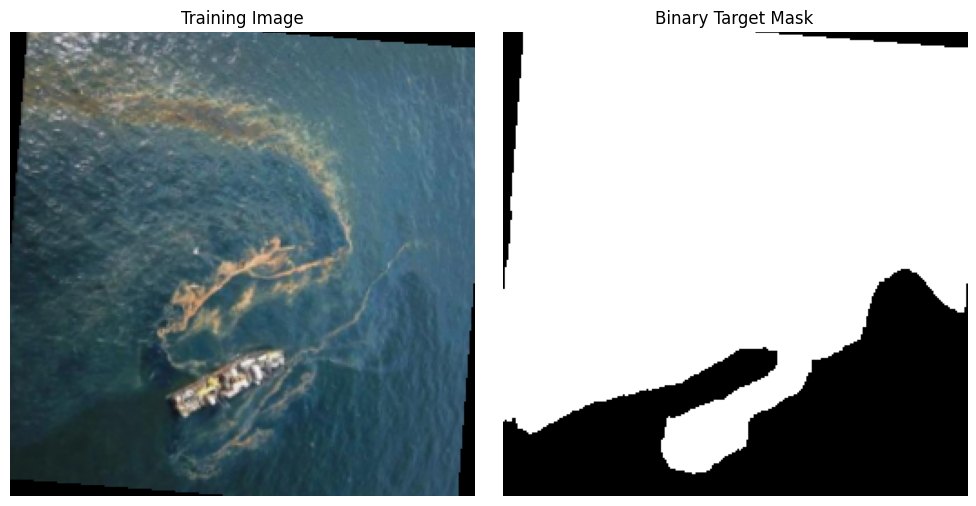

In [11]:
image, mask = train_dataset[0]

image_np = image.permute(1, 2, 0).numpy()
mask_np = mask.squeeze(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_np)
axes[0].set_title("Training Image")
axes[0].axis("off")

axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Binary Target Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. DataLoaders and Experiment Configuration

In [12]:
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 149
Validation batches: 43
Test batches: 22


## 7. U-Net Baseline Model

The baseline uses the PetroVision U-Net implementation with BCE + Dice loss.

In [13]:
model = UNet().to(DEVICE)

criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", trainable_params)
print("Loss:", criterion.__class__.__name__)
print("Optimizer:", optimizer.__class__.__name__)

Trainable parameters: 1942577
Loss: BCEDiceLoss
Optimizer: Adam


## 8. Training

The model is trained using the training split and monitored using the
validation split. The checkpoint with the lowest validation loss is saved.

In [14]:
MODEL_DIR = DRIVE_ROOT / "models"
RESULTS_DIR = DRIVE_ROOT / "results" / "cv_unet_001"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "cv_unet_001_best.pt"
HISTORY_PATH = RESULTS_DIR / "training_history.json"

history = {
    "train_loss": [],
    "validation_loss": []
}

best_val_loss = float("inf")
best_epoch = None

for epoch in range(EPOCHS):

    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(valid_loader)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "experiment_id": "CV-UNET-001",
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": best_val_loss,
                "image_size": IMAGE_SIZE,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "loss_function": criterion.__class__.__name__,
            },
            BEST_MODEL_PATH
        )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
    )

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=4)

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", BEST_MODEL_PATH)

Epoch 01/20 | Train Loss: 0.525336 | Validation Loss: 0.516059
Epoch 02/20 | Train Loss: 0.500047 | Validation Loss: 0.497851
Epoch 03/20 | Train Loss: 0.491594 | Validation Loss: 0.500613
Epoch 04/20 | Train Loss: 0.488300 | Validation Loss: 0.497274
Epoch 05/20 | Train Loss: 0.482721 | Validation Loss: 0.531343
Epoch 06/20 | Train Loss: 0.475296 | Validation Loss: 0.468188
Epoch 07/20 | Train Loss: 0.475723 | Validation Loss: 0.462580
Epoch 08/20 | Train Loss: 0.460409 | Validation Loss: 0.517964
Epoch 09/20 | Train Loss: 0.449629 | Validation Loss: 0.446287
Epoch 10/20 | Train Loss: 0.438018 | Validation Loss: 0.447709
Epoch 11/20 | Train Loss: 0.429169 | Validation Loss: 0.450849
Epoch 12/20 | Train Loss: 0.427206 | Validation Loss: 0.434052
Epoch 13/20 | Train Loss: 0.420091 | Validation Loss: 0.435293
Epoch 14/20 | Train Loss: 0.410280 | Validation Loss: 0.420724
Epoch 15/20 | Train Loss: 0.405106 | Validation Loss: 0.448766
Epoch 16/20 | Train Loss: 0.399236 | Validation Loss: 0

## 9. Training Analysis

The training and validation loss curves are plotted from the recorded
training history.

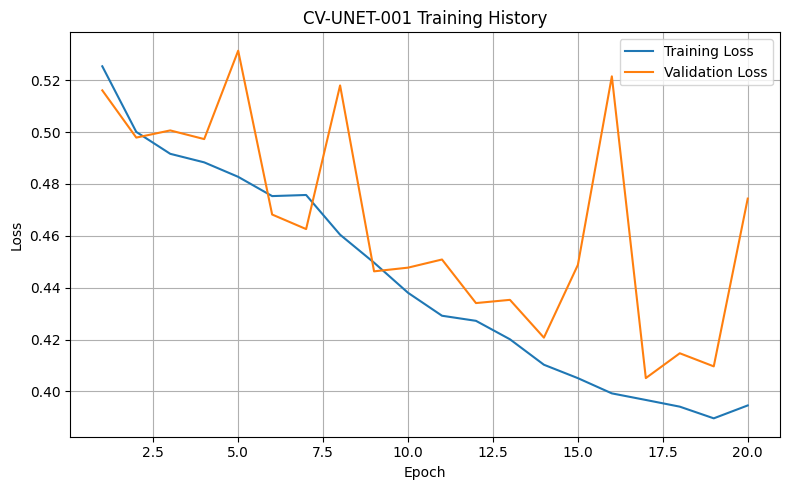

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_loss"], label="Training Loss")
plt.plot(epochs, history["validation_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-UNET-001 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Test Evaluation

The best validation checkpoint is evaluated on the unseen test split.
Predictions are converted into binary masks using a threshold of 0.5.

In [16]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

TP = FP = FN = TN = 0

with torch.no_grad():
    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        TP += ((predictions == 1) & (masks == 1)).sum().item()
        FP += ((predictions == 1) & (masks == 0)).sum().item()
        FN += ((predictions == 0) & (masks == 1)).sum().item()
        TN += ((predictions == 0) & (masks == 0)).sum().item()

iou = TP / (TP + FP + FN) if (TP + FP + FN) else 0.0

dice = (
    2 * TP / (2 * TP + FP + FN)
    if (2 * TP + FP + FN)
    else 0.0
)

precision = (
    TP / (TP + FP)
    if (TP + FP)
    else 0.0
)

recall = (
    TP / (TP + FN)
    if (TP + FN)
    else 0.0
)

accuracy = (
    (TP + TN) / (TP + TN + FP + FN)
    if (TP + TN + FP + FN)
    else 0.0
)

metrics = {
    "experiment_id": checkpoint["experiment_id"],
    "best_epoch": checkpoint["epoch"],
    "validation_loss": checkpoint["validation_loss"],
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN
}

print(json.dumps(metrics, indent=4))

{
    "experiment_id": "CV-UNET-001",
    "best_epoch": 17,
    "validation_loss": 0.40512764384580213,
    "IoU": 0.6497578850953283,
    "Dice": 0.7877008995871939,
    "Precision": 0.7665690268091739,
    "Recall": 0.8100308775165109,
    "Accuracy": 0.7675129971073251,
    "TP": 9695181,
    "FP": 2952318,
    "FN": 2273722,
    "TN": 7557627
}


In [17]:
METRICS_PATH = RESULTS_DIR / "test_metrics.json"

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved to:", METRICS_PATH)

Metrics saved to: /content/drive/MyDrive/PetroVision/results/cv_unet_001/test_metrics.json


## 11. Test Performance Visualization

The following chart is generated directly from the evaluated test metrics.

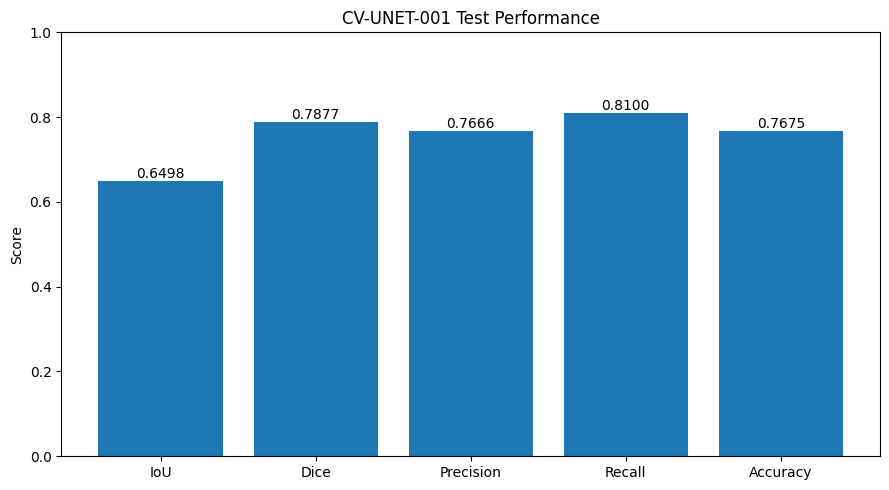

In [18]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

metric_values = [
    metrics[name]
    for name in metric_names
]

plt.figure(figsize=(9, 5))

bars = plt.bar(metric_names, metric_values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CV-UNET-001 Test Performance")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 12. Qualitative Analysis

Predictions are visualized with the original image, ground-truth mask,
predicted mask, and overlay.

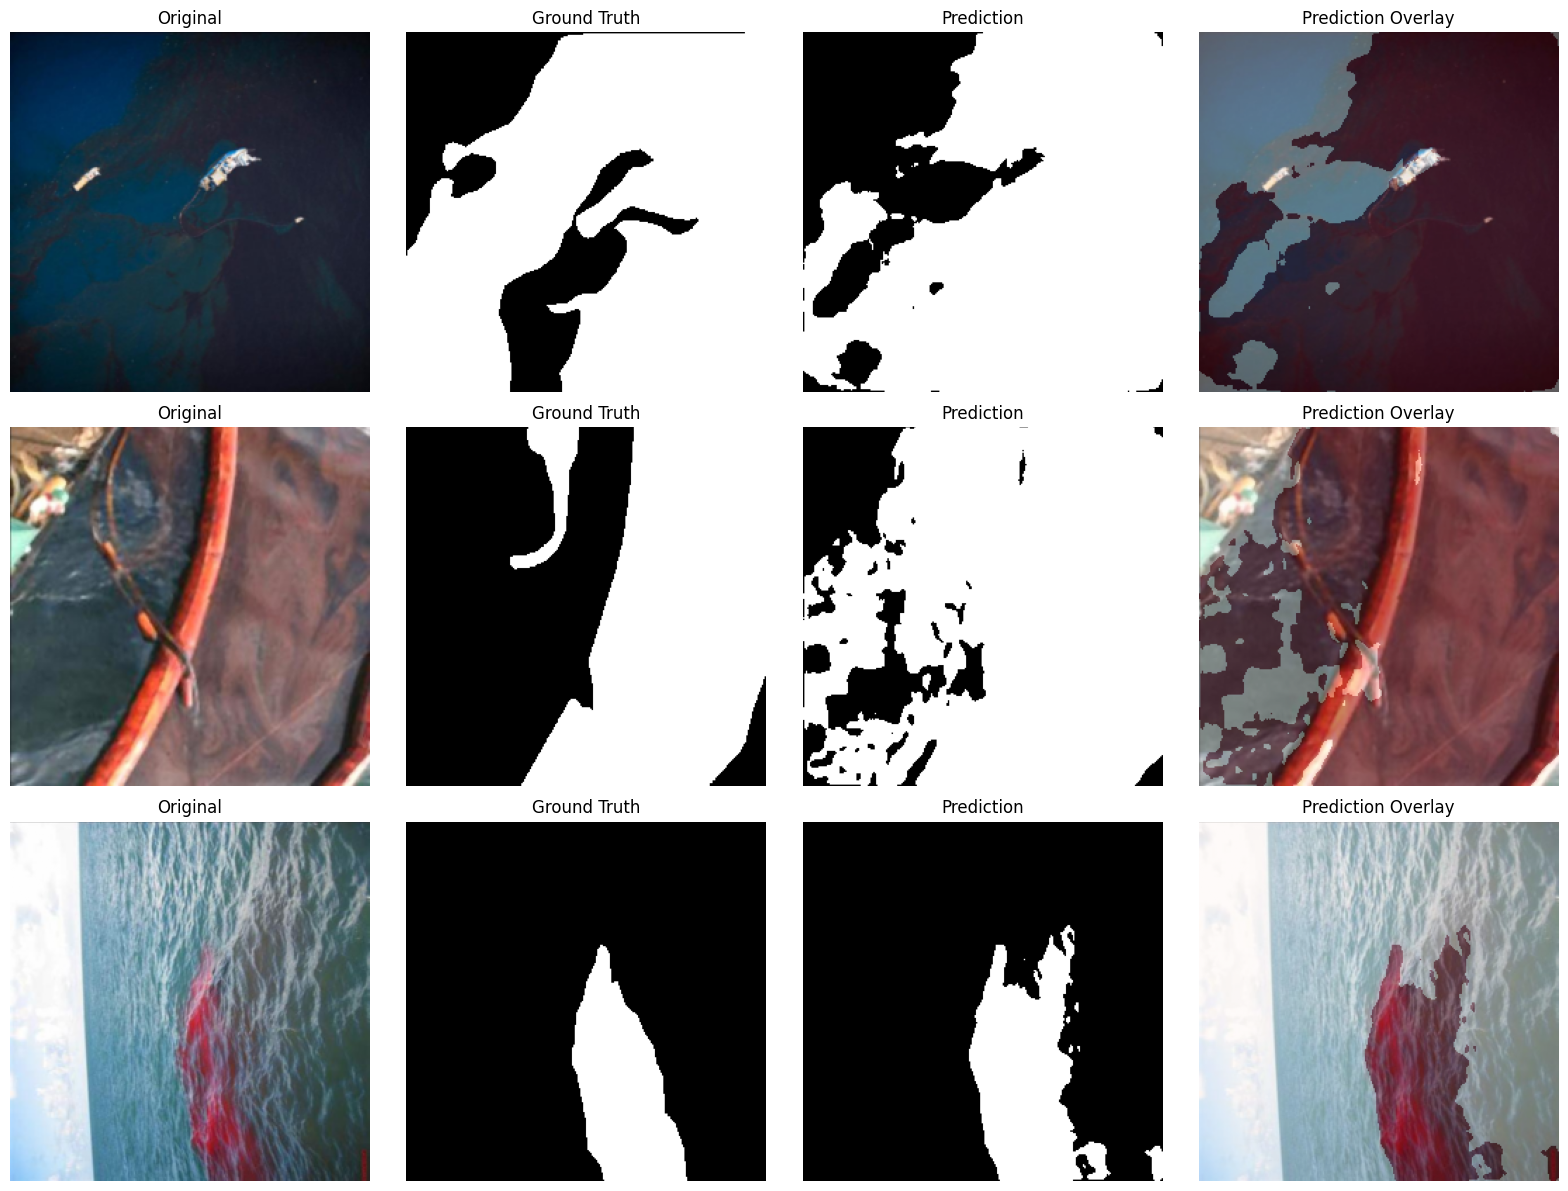

In [19]:
sample_indices = [0, 100, 200]

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

model.eval()

with torch.no_grad():
    for row, index in enumerate(sample_indices):

        image, mask = test_dataset[index]

        input_tensor = image.unsqueeze(0).to(DEVICE)

        prediction = torch.sigmoid(
            model(input_tensor)
        )[0, 0].cpu().numpy()

        prediction_binary = prediction >= 0.5

        image_np = image.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze(0).numpy()

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title("Original")

        axes[row, 1].imshow(mask_np, cmap="gray")
        axes[row, 1].set_title("Ground Truth")

        axes[row, 2].imshow(prediction_binary, cmap="gray")
        axes[row, 2].set_title("Prediction")

        axes[row, 3].imshow(image_np)
        axes[row, 3].imshow(
            prediction_binary,
            alpha=0.35,
            cmap="Reds"
        )
        axes[row, 3].set_title("Prediction Overlay")

        for col in range(4):
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 13. Pixel-Level Error Analysis

The total TP, FP, FN, and TN counts from the test evaluation are visualized
to understand the model's pixel-level errors.

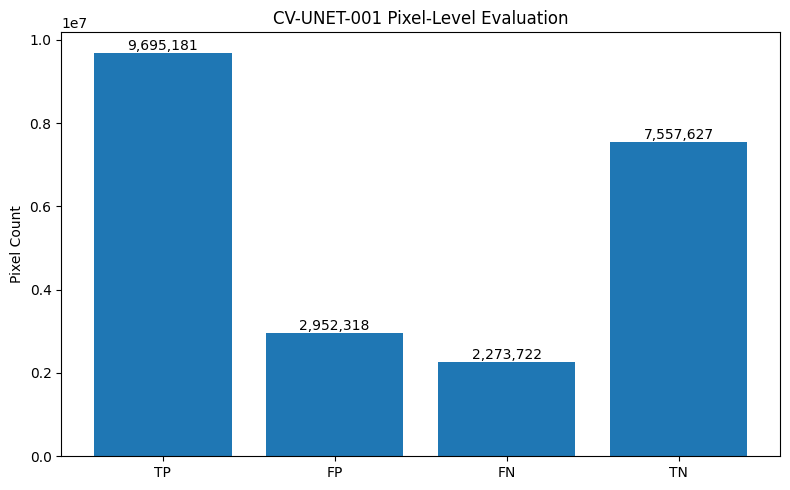

In [20]:
error_names = ["TP", "FP", "FN", "TN"]
error_values = [metrics[name] for name in error_names]

plt.figure(figsize=(8, 5))

bars = plt.bar(error_names, error_values)

plt.ylabel("Pixel Count")
plt.title("CV-UNET-001 Pixel-Level Evaluation")

for bar, value in zip(bars, error_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 14. Experiment Outputs

The trained checkpoint, training history, and test metrics are saved for
reproducibility and for use by later PetroVision experiments.

In [21]:
print("Experiment:", metrics["experiment_id"])
print("Checkpoint:", BEST_MODEL_PATH)
print("Training history:", HISTORY_PATH)
print("Test metrics:", METRICS_PATH)

Experiment: CV-UNET-001
Checkpoint: /content/drive/MyDrive/PetroVision/models/cv_unet_001_best.pt
Training history: /content/drive/MyDrive/PetroVision/results/cv_unet_001/training_history.json
Test metrics: /content/drive/MyDrive/PetroVision/results/cv_unet_001/test_metrics.json
